## Project 9 - Dates and Date-Times - Sarah Liu

In [1]:
'''
/anvil/projects/tdm/data/restaurant/orders.csv
/anvil/projects/tdm/data/flights/subset/1997.csv
'''

'\n/anvil/projects/tdm/data/restaurant/orders.csv\n/anvil/projects/tdm/data/flights/subset/1997.csv\n'

In [22]:
import pandas as pd

orders = pd.read_csv('/anvil/projects/tdm/data/restaurant/orders.csv')
orders.shape

/tmp/ipykernel_1041/1019416280.py:3: DtypeWarning: Columns (15,16,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  orders = pd.read_csv('/anvil/projects/tdm/data/restaurant/orders.csv')


(135303, 26)

In [23]:
pd.set_option('display.max_columns', None)

In [24]:
orders.head()

,akeed_order_id,customer_id,item_count,grand_total,payment_mode,promo_code,vendor_discount_amount,promo_code_discount_percentage,is_favorite,is_rated,vendor_rating,driver_rating,deliverydistance,preparationtime,delivery_time,order_accepted_time,driver_accepted_time,ready_for_pickup_time,picked_up_time,delivered_time,delivery_date,vendor_id,created_at,LOCATION_NUMBER,LOCATION_TYPE,CID X LOC_NUM X VENDOR
0,163238.0,92PEE24,1.0,7.6,2,NaN,0.0,NaN,NaN,No,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,105,2019-08-01 05:30:16,0,NaN,92PEE24 X 0 X 105
1,163240.0,QS68UD8,1.0,8.7,1,NaN,0.0,NaN,NaN,No,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,294,2019-08-01 05:31:10,0,Work,QS68UD8 X 0 X 294
2,163241.0,MB7VY5F,2.0,14.4,1,NaN,0.0,NaN,NaN,No,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,83,2019-08-01 05:31:33,0,NaN,MB7VY5F X 0 X 83
3,163244.0,KDJ951Y,1.0,7.1,1,NaN,0.0,NaN,NaN,No,NaN,0.0,0.0,NaN,2019-08-01 04:03:00,NaN,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,90,2019-08-01 05:34:54,0,Home,KDJ951Y X 0 X 90
4,163245.0,BAL0RVT,4.0,27.2,1,NaN,0.0,NaN,NaN,No,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,83,2019-08-01 05:35:51,0,Work,BAL0RVT X 0 X 83


In [25]:
#1.1 convert created_at to datetime
orders['created_at'] = pd.to_datetime(orders['created_at'])

In [26]:
#1.2 use datetimme for easy extraction of components w a time (year, month, day) 

In [27]:
orders["num_day_of_the_week"] = orders["created_at"].dt.dayofweek
orders["day_of_the_week"] = orders["created_at"].dt.day_name()
print(orders[["created_at", "num_day_of_the_week", "day_of_the_week"]].head())

           created_at  num_day_of_the_week day_of_the_week
0 2019-08-01 05:30:16                    3        Thursday
1 2019-08-01 05:31:10                    3        Thursday
2 2019-08-01 05:31:33                    3        Thursday
3 2019-08-01 05:34:54                    3        Thursday
4 2019-08-01 05:35:51                    3        Thursday


In [28]:
#1.3 yes the days match, monday = 0, sunday = 6

In [29]:
#2.1 
orders["month"] = orders["created_at"].dt.month_name()
orders["year"] = orders["created_at"].dt.year

In [30]:
#2.2 the actual time span runs from may 10 2019 to Feb 29 2020
orders.loc[orders["month"] == "May"]
print(orders['created_at'].min())
print(orders['created_at'].max())

2019-05-10 20:59:58
2020-02-29 23:52:14


In [31]:
# 2.3 distribution of orders by year and month
monthly_distribution = orders.groupby(['year', 'month'])['item_count'].sum().unstack()
print(monthly_distribution)

month   August  December  February  January     July     June  May  November  \
year                                                                           
2019   23853.0   47479.0       NaN      NaN  27296.0  27839.0  0.0   43102.0   
2020       NaN       NaN   51197.0  40410.0      NaN      NaN  NaN       NaN   

month  October  September  
year                       
2019   31527.0    16098.0  
2020       NaN        NaN  


In [41]:
flights = pd.read_csv('/anvil/projects/tdm/data/flights/subset/1997.csv')
#3.1 create full date column
flights["full_dates"] = pd.to_datetime(flights.rename(columns={'Year': 'year','Month': 'month','DayofMonth': 'day'})[['year', 'month', 'day']])

In [42]:
# 3.2 Create the hour and minute columns AND convert to timedelta
flights["depHour"] = pd.to_timedelta(flights["DepTime"] // 100, unit='h')
flights["depMinute"] = pd.to_timedelta(flights["DepTime"] % 100, unit='m')

In [45]:
# 3.3 create date_times column w/ year, month, day, hour, and minute
flights["date_times"] = flights["full_dates"] + flights["depHour"] + flights["depMinute"]

In [46]:
flights[["DepTime","full_dates", "date_times"]].head()

,DepTime,full_dates,date_times
0,1615.0,1997-01-28,1997-01-28 16:15:00
1,1624.0,1997-01-29,1997-01-29 16:24:00
2,1626.0,1997-01-30,1997-01-30 16:26:00
3,1628.0,1997-01-31,1997-01-31 16:28:00
4,1503.0,1997-01-14,1997-01-14 15:03:00


In [ ]:
'''
4.1 the calendar library is good for mapping numerical values to full month or day names,
or handing leap year logic. It also sorts data based on date rather than alphabetically. 
'''

In [47]:
#4.2
import calendar
flights['Month_Names'] = flights['Month'].apply(lambda x: calendar.month_name[x])

# correct chronological order January->December
month_order = list(calendar.month_name)[1:]

flights['Month_Names'] = pd.Categorical(
    flights['Month_Names'], 
    categories=month_order, 
    ordered=True
)

In [49]:
# 4.3 bostonDF subset
bostonDF = flights[flights['Origin'] == 'BOS']
# value counts of Month_Names
print(bostonDF['Month_Names'].value_counts(sort=False))

Month_Names
January      8271
February     7371
March        8302
April        8182
May          8278
June         8265
July         8550
August       8504
September    8208
October      8515
November     7851
December     7971
Name: count, dtype: int64


In [51]:
#5.1 create df for 4 cols (bostonDF alr created ^)
phoenixDF = flights[flights["Origin"] == "PHX"]
chicagoDF = flights[flights["Origin"] == "MDW"]
seattleDF = flights[flights["Origin"] == "SEA"]

# calculate avg distance/month for each
boston_distance = bostonDF.groupby('Month_Names', observed=True)["Distance"].mean()
phoenix_distance = phoenixDF.groupby('Month_Names', observed=True)["Distance"].mean()
chicago_distance = chicagoDF.groupby('Month_Names', observed=True)["Distance"].mean()
seattle_distance = seattleDF.groupby('Month_Names', observed=True)["Distance"].mean()

In [52]:
# 5.2 combine into the my_distances DataFrame
my_distances = pd.DataFrame({
    'BOS': boston_distance, 
    'PHX': phoenix_distance, 
    'MDW': chicago_distance, 
    'SEA': seattle_distance
})

print(my_distances)

                    BOS         PHX         MDW          SEA
Month_Names                                                 
January      899.699190  751.851651  359.147939  1052.647174
February     893.662461  755.998288  358.540807  1050.157120
March        893.584558  758.414942  359.513528  1054.616615
April        895.018822  750.131354  360.956631  1062.143961
May          895.601836  747.255099  361.489183  1093.356530
June         886.292075  741.510192  361.372528  1144.422355
July         889.224795  743.758962  361.720955  1157.622487
August       892.835842  747.286225  362.785696  1156.308166
September    882.723806  757.445236  363.684281  1111.635785
October      881.426659  764.540103  363.411399  1092.401393
November     887.897083  771.135844  364.650363  1073.647453
December     895.059215  777.009299  364.429188  1064.165342


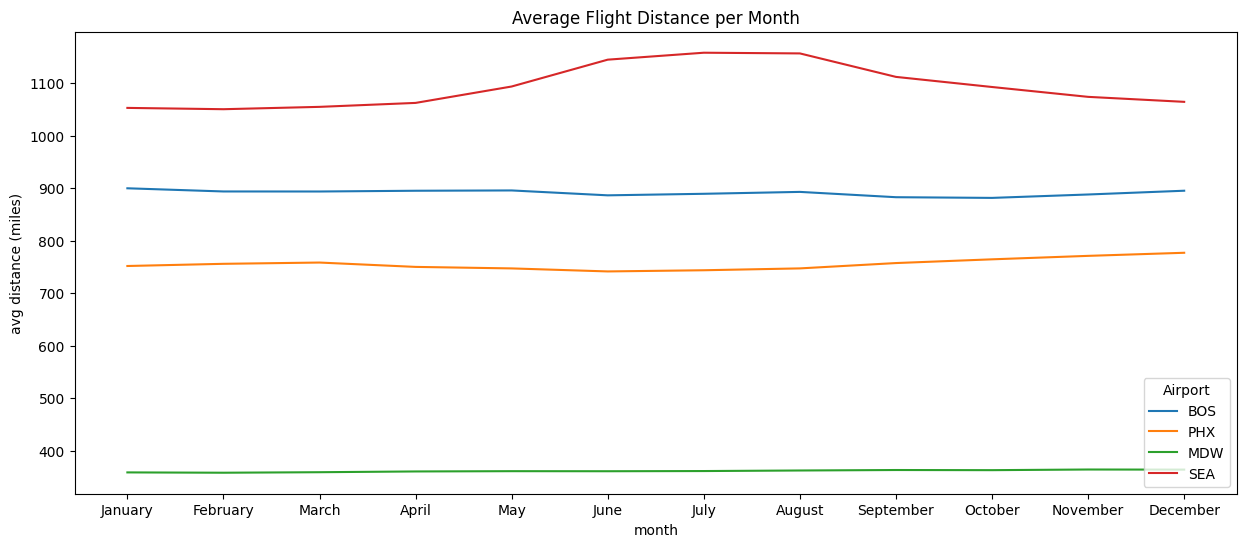

In [59]:
# 5.3 show plot
import matplotlib.pyplot as plt

my_distances.plot(figsize=(15, 6))
plt.title("Average Flight Distance per Month")
plt.xlabel("month")
plt.ylabel("avg distance (miles)")
plt.xticks(ticks=range(len(my_distances.index)), labels=my_distances.index)
plt.legend(title="Airport", loc='lower right')
plt.show()